# **Mestrado em Informática**
# **Pós-Graduação em Data Science and Digital Transformation**

## *(Ambientes de) Programação para Ciência de Dados*

**Mónica Vieira Martins**  
----

># Transformações de escala



# Introdução:


# Dados

Neste tutorial vamos continuar a  utilizar um conjunto de dados referente aos passageiros do [Titanic](https://https://www.kaggle.com/c/titanic/data), para exemplificar a necessidade de normalizar as variáveis.

O ficheiro de dados denomina-se `Titanic.csv`. A descrição das colunas do ficheiro é a seguinte:

>Variável | Significado | Valores
>---------|-------------|---------
>Survival | sobrevivência | 0=Não, 1=Sim  |
>Pclass | classe do bilhete | 1=1ª, 2=2ª, 3=3ª|
> Name | nome | |
>Sex | sexo | male, female |
>Age | idade, em anos | |
>Sibsp | número de irmãos/esposos a bordo||
>Parch | número de pais/filhos a bordo |
>Ticket |	número do bilhete |
>Fare | preço pago  |
> Embarked | porto de embarcação | C=Cherbourg, Q=Queenstown, S=Southampton




In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_style("whitegrid")
import numpy as np


In [2]:
path = "titanic.csv"
df = pd.read_csv(path)

In [3]:
df.shape

(891, 12)

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

*PassengerID* e índice são redundantes, podemos alterar o índice com `set_index()`

In [5]:
df.set_index('PassengerId', inplace=True, drop=True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Atributos com escalas diferentes

Para exemplificar a relevância da normalização de dados, iremos trabalhar com atributos com escalas muito diferentes: `Age` e `Fare`

In [7]:
dados = df[['Age', 'Fare']].copy()
#averiaguar valores em falta
dados.isna().sum()


,0
Age,177
Fare,0


In [8]:
#aplicar SimpleImputer com médias a Age
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
dados['Age'] = imputer.fit_transform(dados[['Age']])
dados.isna().sum()

,0
Age,0
Fare,0


In [34]:
dados.describe()

,Age,Fare
count,891.000000,891.000000
mean,29.699118,32.204208
std,13.002015,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,29.699118,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


Visualizamos a distribuição inicial dos dados

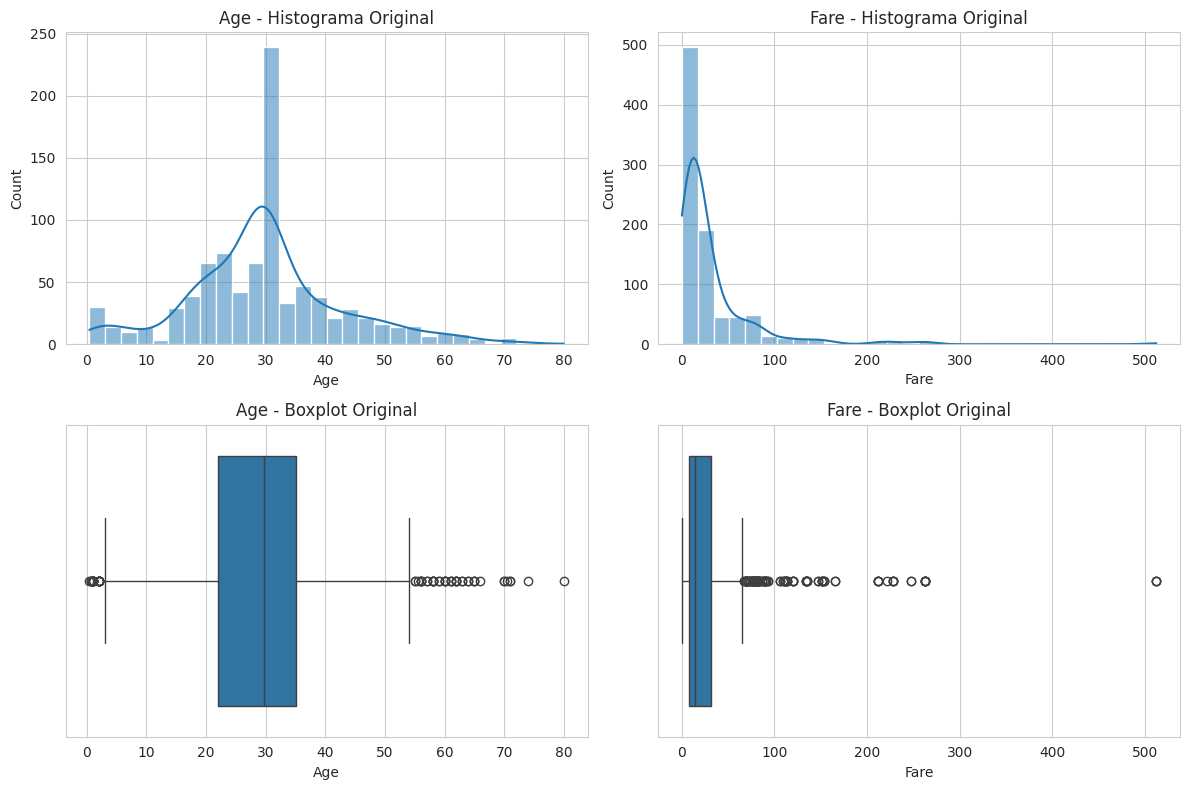

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histogramas
sns.histplot(dados['Age'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age - Histograma Original")

sns.histplot(dados['Fare'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Fare - Histograma Original")

# Boxplots
sns.boxplot(x=dados['Age'], ax=axes[1, 0])
axes[1, 0].set_title("Age - Boxplot Original")

sns.boxplot(x=dados['Fare'], ax=axes[1, 1])
axes[1, 1].set_title("Fare - Boxplot Original")

plt.tight_layout()
plt.show()


Os gráficos acima permitem verificar que
* as escalas das duas variáveis são miuto diferentes: Age: 0-80; Fare: 0-521
* Fare tem cauda muito longa e outliers

## Min-Max scaler

In [11]:
# Importar scalers
from sklearn.preprocessing import  MinMaxScaler

#df para dados transformados
scaled_minmax = dados.copy()
#instaciar minmax scaler
minmax_scaler = MinMaxScaler()
#aplicar transformação
scaled_minmax[['Age', 'Fare']] = minmax_scaler.fit_transform(dados[['Age', 'Fare']])

Comparemos o distribuição dos dados antes de depois da transformação

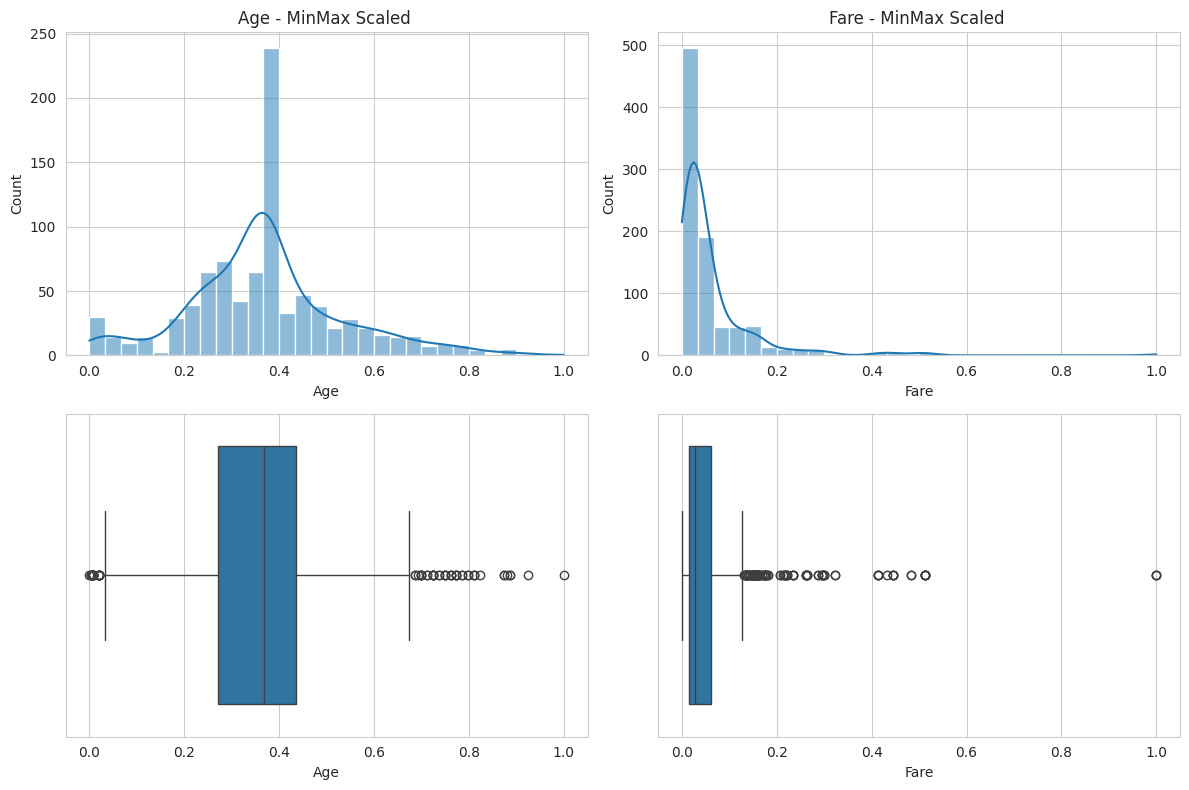

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(scaled_minmax['Age'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age - MinMax Scaled ")

sns.histplot(scaled_minmax['Fare'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Fare - MinMax Scaled ")

sns.boxplot(x=scaled_minmax['Age'], ax=axes[1, 0])

sns.boxplot(x=scaled_minmax['Fare'], ax=axes[1, 1])

plt.tight_layout()
plt.show()


Verifica-se que
* Todos os valores ficam  entre 0 e 1
* `Fare` continua com outlier
* Os valores semelhantes continuam muito "achatados"



## Standard Scaler

In [16]:
from sklearn.preprocessing import StandardScaler

#df para dados transformados
scaled_standard = dados.copy()
#instaciar scaler
standard_scaler = StandardScaler()
#aplicar transformação
scaled_standard[['Age', 'Fare']] = standard_scaler.fit_transform(dados[['Age', 'Fare']])

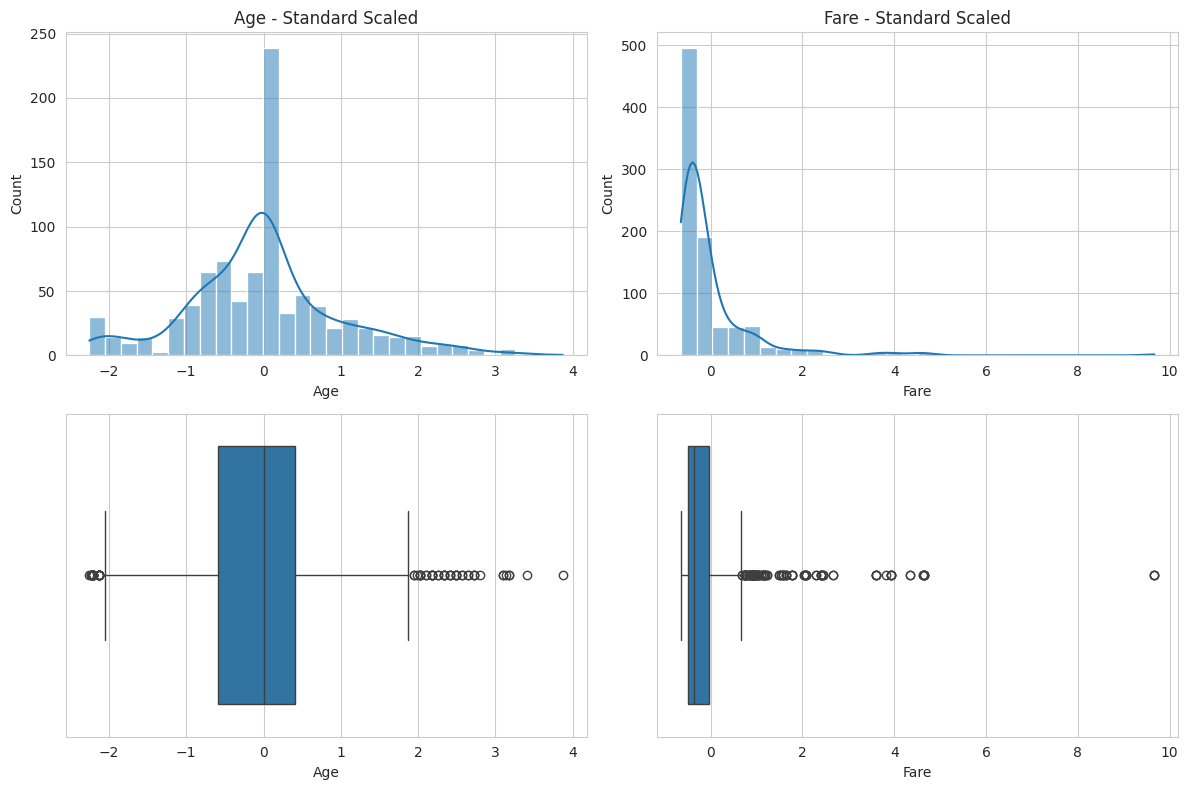

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(scaled_standard['Age'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age - Standard Scaled")

sns.histplot(scaled_standard['Fare'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Fare - Standard Scaled")

sns.boxplot(x=scaled_standard['Age'], ax=axes[1, 0])

sns.boxplot(x=scaled_standard['Fare'], ax=axes[1, 1])

plt.tight_layout()
plt.show()


In [20]:
scaled_standard.describe()

,Age,Fare
count,8.910000e+02,8.910000e+02
mean,2.232906e-16,3.987333e-18
std,1.000562e+00,1.000562e+00
min,-2.253155e+00,-6.484217e-01
25%,-5.924806e-01,-4.891482e-01
50%,0.000000e+00,-3.573909e-01
75%,4.079260e-01,-2.424635e-02
max,3.870872e+00,9.667167e+00


Verificamos que
* as distribuições estão centradas em 0 e o desvio padrão é 1
* Fare continua a ter outliers

## Robust Scaler

In [18]:
from sklearn.preprocessing import RobustScaler

#df para dados transformados
scaled_robust = dados.copy()
#instaciar scaler
robust_scaler = RobustScaler()
#aplicar transformação
scaled_robust[['Age', 'Fare']] = robust_scaler.fit_transform(dados[['Age', 'Fare']])


In [19]:
scaled_robust.describe()

,Age,Fare
count,8.910000e+02,891.000000
mean,2.153160e-16,0.768745
std,1.000155e+00,2.152200
min,-2.252240e+00,-0.626005
25%,-5.922398e-01,-0.283409
50%,0.000000e+00,0.000000
75%,4.077602e-01,0.716591
max,3.869299e+00,21.562738


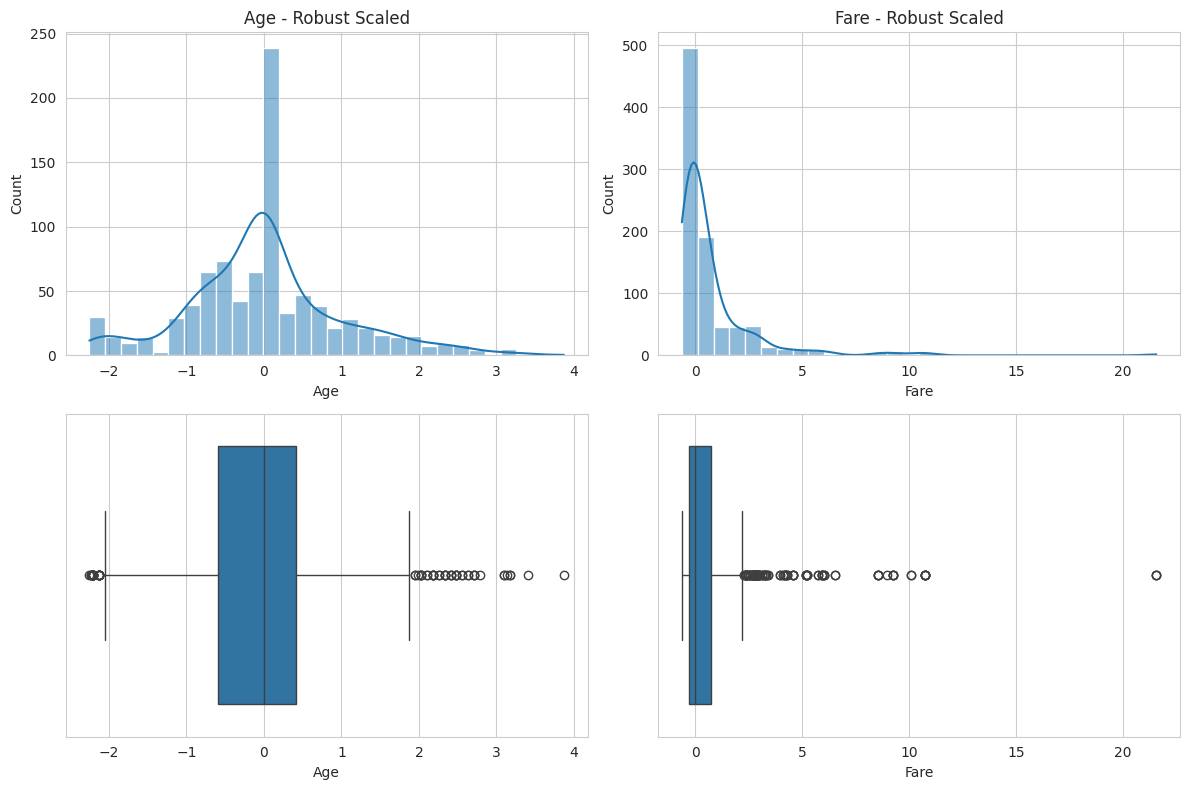

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(scaled_robust['Age'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age - Robust Scaled")

sns.histplot(scaled_robust['Fare'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Fare - Robust Scaled")

sns.boxplot(x=scaled_robust['Age'], ax=axes[1, 0])

sns.boxplot(x=scaled_robust['Fare'], ax=axes[1, 1])

plt.tight_layout()
plt.show()


Outliers de Fare passam a afetar muito menos

Para Age, distribuição com standadrd Scaler e Robust Scaler é muito semelhnate, porque, originalmente, média e mediana deste atributo estão muito próximas.

Boxplot fica “mais equilibrado” em Fare

## Analisar transformações  com base em medidas estatíticas

In [48]:
import numpy as np

def describe_extended(df):
    desc = df.describe().T # count, mean, std, min, 25%, 50%, 75%, max

    return desc

def comparar(atributo):
  stats_original = describe_extended(dados[[atributo]])
  stats_standard = describe_extended(scaled_standard[[atributo]])
  stats_minmax = describe_extended(scaled_minmax[[atributo]])
  stats_robust = describe_extended(scaled_robust[[atributo]])

  # Construir tabela juntando tudo
  tabela = pd.concat(
    {
        "Original": stats_original,
        "MinMaxScaler": stats_minmax,
        "StandardScaler": stats_standard,
         "RobustScaler": stats_robust,
    },
    axis=0
  )
  return tabela.T



In [49]:
comparar("Age")

,Original,MinMaxScaler,StandardScaler,RobustScaler
,Age,Age,Age,Age
count,891.000000,891.000000,8.910000e+02,8.910000e+02
mean,29.699118,0.367921,2.232906e-16,2.153160e-16
std,13.002015,0.163383,1.000562e+00,1.000155e+00
min,0.420000,0.000000,-2.253155e+00,-2.252240e+00
25%,22.000000,0.271174,-5.924806e-01,-5.922398e-01
50%,29.699118,0.367921,0.000000e+00,0.000000e+00
75%,35.000000,0.434531,4.079260e-01,4.077602e-01
max,80.000000,1.000000,3.870872e+00,3.869299e+00


In [50]:
comparar("Fare")

,Original,MinMaxScaler,StandardScaler,RobustScaler
,Fare,Fare,Fare,Fare
count,891.000000,891.000000,8.910000e+02,891.000000
mean,32.204208,0.062858,3.987333e-18,0.768745
std,49.693429,0.096995,1.000562e+00,2.152200
min,0.000000,0.000000,-6.484217e-01,-0.626005
25%,7.910400,0.015440,-4.891482e-01,-0.283409
50%,14.454200,0.028213,-3.573909e-01,0.000000
75%,31.000000,0.060508,-2.424635e-02,0.716591
max,512.329200,1.000000,9.667167e+00,21.562738
